# YouTube Trending Videos EDA

This notebook reads the cleaned CSV produced from the raw trending dataset and answers the EDA requirements with tables, plots, and short interpretations.

## Introduction

The goal is to understand which video characteristics are associated with trending performance. The analysis is organized around the project objectives rather than around isolated charts.

## Problem Statement

Content creators and marketing teams need to understand which YouTube video characteristics are associated with trending performance. This analysis examines views, engagement, timing, channels, categories, and tags to identify patterns that can inform content strategy.

## Objectives

- Summarize the cleaned dataset and key numeric distributions.
- Analyze univariate distributions, time patterns, channel and category performance, correlations, tags, and outliers.
- Turn the results into practical recommendations.

## Exploratory Data Analysis

### Data Info

Load the cleaned CSV and inspect the schema before deeper analysis.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid", context="notebook")

CLEAN_PATHS = [
    Path("data/processed/youtube_clean.csv"),
    Path("../data/processed/youtube_clean.csv"),
    Path("../../data/processed/youtube_clean.csv"),
]
for candidate in CLEAN_PATHS:
    if candidate.exists():
        CLEAN_PATH = candidate
        break
else:
    raise FileNotFoundError("Could not find data/processed/youtube_clean.csv")

df = pd.read_csv(CLEAN_PATH)
for column in ["trending_date", "publish_date"]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")
for column in ["category_id", "views", "likes", "dislikes", "comment_count", "published_hour", "days_to_trend", "tag_count", "days_trending"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
for column in ["comments_disabled", "ratings_disabled", "video_error_or_removed", "metric_issue_flag"]:
    if column in df.columns:
        series = df[column].astype("string").str.strip().str.lower()
        df[column] = series.map({"true": True, "false": False}).astype("boolean")

df.head()

,video_id,trending_date,title,channel_title,category_id,category_label,publish_date,time_frame,published_hour,published_day_of_week,publish_country,tags,tags_clean,tag_count,views,likes,dislikes,comment_count,engagement_rate,like_ratio,days_to_trend,days_trending,unique_video_key,comments_disabled,ratings_disabled,video_error_or_removed,metric_issue_flag
0,0PkVodF5QQ8,2017-11-14,"ValÃ©rie Plante, la premiÃ¨re mairesse de Mont...",mart lat,24,Entertainment,2017-11-13,2:00 to 2:59,2,Monday,CANADA,"ValÃ©rie Plante|""mairesse""|""MontrÃ©al""|""Tout L...",valã©rie plante|mairesse|montrã©al|tout le mon...,6,9368,75,15,28,0.010995,0.833333,1,2,CANADA::0PkVodF5QQ8,False,False,False,False
1,0PpNlNJ6Nng,2017-11-14,Will It Watermarble?! Sister Edition | Waterma...,Simply Nailogical,24,Entertainment,2017-11-11,19:00 to 19:59,19,Saturday,CANADA,"nails|""nail art""|""nail tutorial""|""beauty tutor...",nails|nail art|nail tutorial|beauty tutorial|n...,26,1842393,99086,1339,11800,0.060186,0.986667,3,1,CANADA::0PpNlNJ6Nng,False,False,False,False
2,0RFhWyM6qbA,2017-11-14,Benzema balance ses dur vÃ©ritÃ©s Deschamps et...,HALIRIPA,22,People & Blogs,2017-11-12,20:00 to 20:59,20,Sunday,CANADA,"Karim benzema football|""Benzema vs cristiano r...",karim benzema football|benzema vs cristiano ro...,3,635236,5945,722,1483,0.011693,0.891705,2,1,CANADA::0RFhWyM6qbA,False,False,False,False
3,0aYWB3d7bJ8,2017-11-14,ã€Fullã€‘ã€Šæžé™æŒ‘æˆ˜IIIã€‹ç¬¬11æœŸ2017111...,SMGä¸Šæµ·ç”µè§†å°å®˜æ–¹é¢‘é“ SMG Shanghai TV...,24,Entertainment,2017-11-10,17:00 to 17:59,17,Friday,CANADA,"æžé™æŒ‘æˆ˜|""æžé™æŒ‘æˆ˜ 20171110""|""æžé™æŒ...",æžé™æœ‘æˆ˜|æžé™æœ‘æˆ˜ 20171110|æžé™æœ‘æˆ...,45,738561,2519,224,1014,0.004784,0.918338,4,1,CANADA::0aYWB3d7bJ8,False,False,False,False
4,0dBIkQ4Mz1M,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,Comedy,2017-11-13,17:00 to 17:59,17,Monday,CANADA,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",plush|bad unboxing|unboxing|fan mail|idubbbztv...,11,1014651,127794,1688,13030,0.138791,0.986963,1,5,CANADA::0dBIkQ4Mz1M,False,False,False,False


In [2]:
print("shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())
print("\ndtypes:")
print(df.dtypes)

print("\ninfo:")
df.info()


shape: (161470, 27)

columns:
['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'category_label', 'publish_date', 'time_frame', 'published_hour', 'published_day_of_week', 'publish_country', 'tags', 'tags_clean', 'tag_count', 'views', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'like_ratio', 'days_to_trend', 'days_trending', 'unique_video_key', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'metric_issue_flag']

dtypes:
video_id                             str
trending_date             datetime64[us]
title                                str
channel_title                        str
category_id                        int64
category_label                       str
publish_date              datetime64[us]
time_frame                           str
published_hour                     int64
published_day_of_week                str
publish_country                      str
tags                                 str
tags_clean                     

In [3]:
numeric_summary = df.select_dtypes(include=["number"]).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
display(numeric_summary)

missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))

display(df.sample(5, random_state=42))

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
category_id,161470.0,1.946115e+01,7.432001e+00,1.0,15.000000,23.000000,2.400000e+01,2.600000e+01,2.700000e+01,2.800000e+01,4.400000e+01
published_hour,161470.0,1.383164e+01,6.209498e+00,0.0,10.000000,15.000000,1.800000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.300000e+01
tag_count,161470.0,1.785069e+01,1.247673e+01,0.0,8.000000,16.000000,2.600000e+01,3.500000e+01,4.000000e+01,5.100000e+01,1.240000e+02
views,161470.0,2.419854e+06,1.043749e+07,223.0,101538.250000,384739.500000,1.339528e+06,4.173845e+06,9.212629e+06,3.982492e+07,4.245389e+08
likes,161470.0,6.566194e+04,2.260617e+05,0.0,1975.000000,9840.000000,4.006275e+04,1.461419e+05,2.864191e+05,9.754290e+05,5.613827e+06
dislikes,161470.0,3.490153e+03,3.114779e+04,0.0,85.000000,348.000000,1.350000e+03,5.052000e+03,1.133055e+04,4.942455e+04,1.944971e+06
comment_count,161470.0,7.035494e+03,3.404121e+04,0.0,279.000000,1144.000000,4.144750e+03,1.366000e+04,2.723700e+04,8.790900e+04,1.626501e+06
engagement_rate,161470.0,4.160270e-02,3.718020e-02,0.0,0.014351,0.031276,5.748851e-02,8.978249e-02,1.144022e-01,1.723244e-01,5.282847e-01
like_ratio,160032.0,9.315367e-01,9.910255e-02,0.0,0.923404,0.965850,9.832775e-01,9.906122e-01,9.934793e-01,9.973058e-01,1.000000e+00
days_to_trend,161470.0,1.471127e+01,1.451923e+02,0.0,1.000000,3.000000,7.000000e+00,1.400000e+01,2.200000e+01,3.500000e+01,4.215000e+03


,missing_count
tags_clean,11234
like_ratio,1438


,video_id,trending_date,title,channel_title,category_id,category_label,publish_date,time_frame,published_hour,published_day_of_week,publish_country,tags,tags_clean,tag_count,views,likes,dislikes,comment_count,engagement_rate,like_ratio,days_to_trend,days_trending,unique_video_key,comments_disabled,ratings_disabled,video_error_or_removed,metric_issue_flag
23971,CoS4RmuzYjY,2018-03-16,HOW I APPLY MAGNETIC FALSE LASHES | No Glue!!!!,KathleenLights,26,Howto & Style,2018-03-14,22:00 to 22:59,22,Wednesday,CANADA,"klpolish|""how to""|""apply""|""false""|""lashes""|""ma...",klpolish|how to|apply|false|lashes|magnetic|fa...,16,187877,12733,103,776,0.071903,0.991976,2,2,CANADA::CoS4RmuzYjY,False,False,False,False
102376,ziLWPlVN0MM,2018-02-27,Jedi Night: The Death of Caleb Dume | Star War...,Disney XD,24,Entertainment,2018-02-20,2:00 to 2:59,2,Tuesday,GB,"disney xd|""disney""|""xd""|""star wars""|""rebels""|""...",disney xd|disney|xd|star wars|rebels|kanan|die...,35,910907,13545,959,6315,0.021802,0.933880,7,24,GB::ziLWPlVN0MM,False,False,False,False
47446,rWWi2sTgMKo,2017-12-16,Trump veut la Lune #cdanslair 15.12.2017,C dans l'air,24,Entertainment,2017-12-15,18:00 to 18:59,18,Friday,FRANCE,"lune""|""espace""|""Chine""|""Etats-Unis""|""trump""|""n...",lune|espace|chine|etats-unis|trump|nasa|chinoi...,16,6012,50,12,0,0.008317,0.806452,1,1,FRANCE::rWWi2sTgMKo,True,False,False,False
159272,1J76wN0TPI4,2018-06-04,Sanju | Official Trailer | Ranbir Kapoor | Raj...,FoxStarHindi,24,Entertainment,2018-05-30,7:00 to 7:59,7,Wednesday,US,"Sanju|""Official Trailer""""|""""sanju official tra...",sanju|official trailer|sanju official trailer|...,20,32582944,711812,26632,53025,0.023474,0.963935,5,14,US::1J76wN0TPI4,False,False,False,False
54821,iw1oMSyz52I,2018-01-24,DEBAT : plainte contre KABILA Ã la CPI + lâ€™...,CleboaPointCom News,20,Gaming,2018-01-23,11:00 to 11:59,11,Tuesday,FRANCE,"cleboa.com""|""clc""|""cenco""|""ceni""|""rassopp",cleboa.com|clc|cenco|ceni|rassopp,5,19795,102,15,45,0.007426,0.871795,1,1,FRANCE::iw1oMSyz52I,False,False,False,False


### Descriptive Statistics

The numeric fields are highly skewed, especially views and likes, so the next charts use log scaling where it helps interpretation.

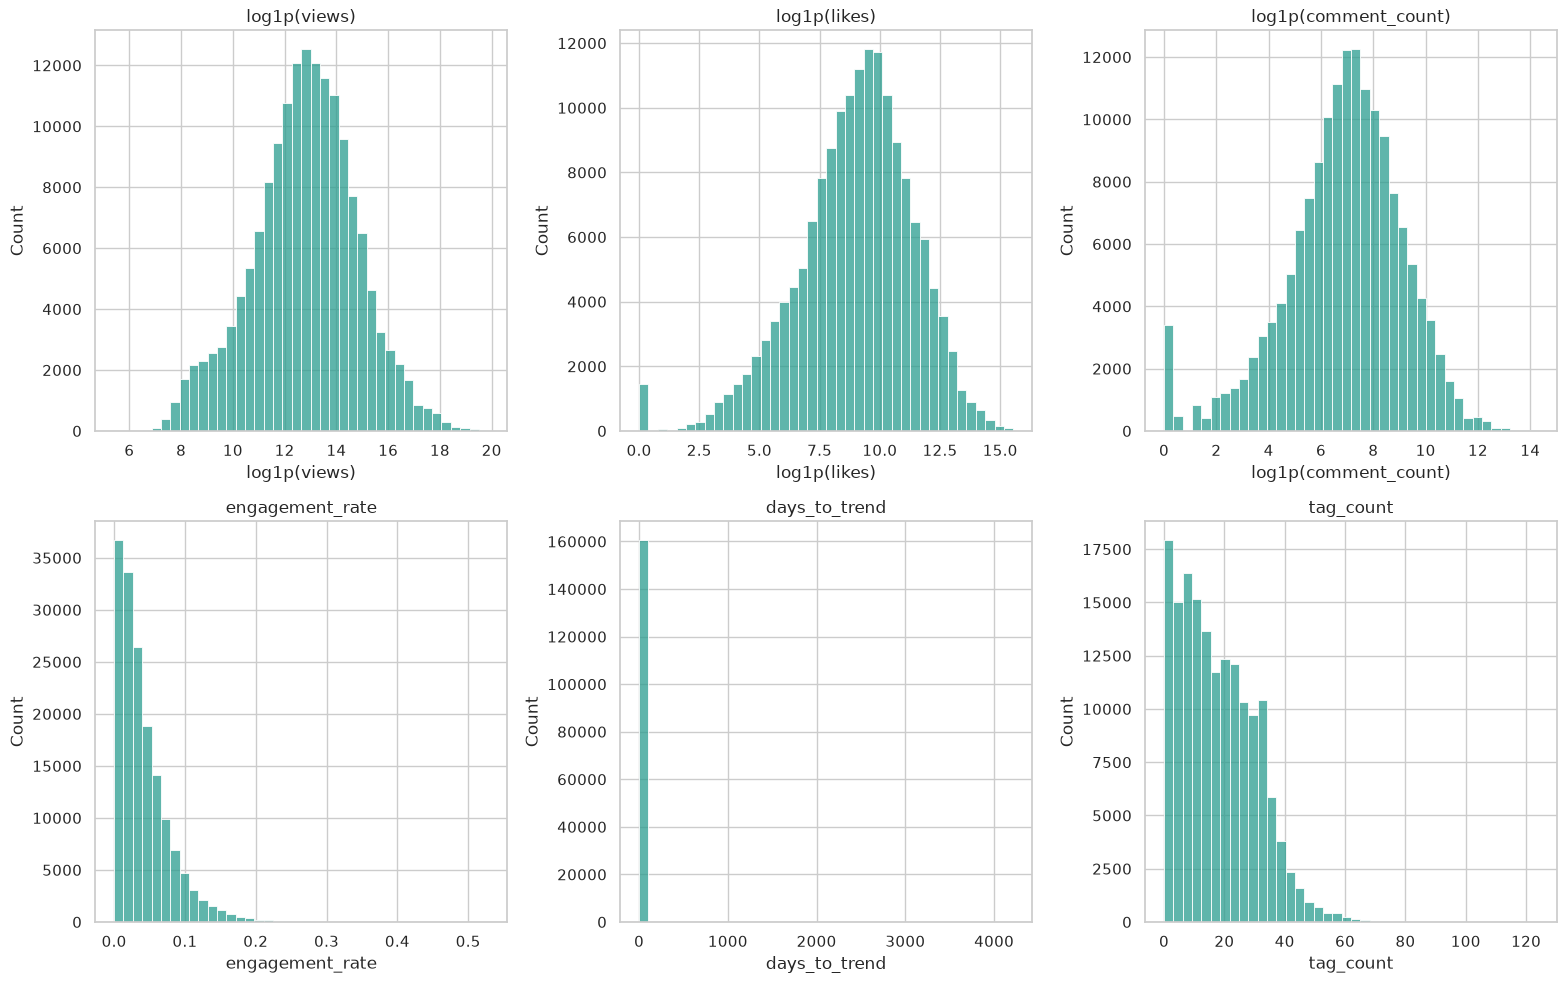

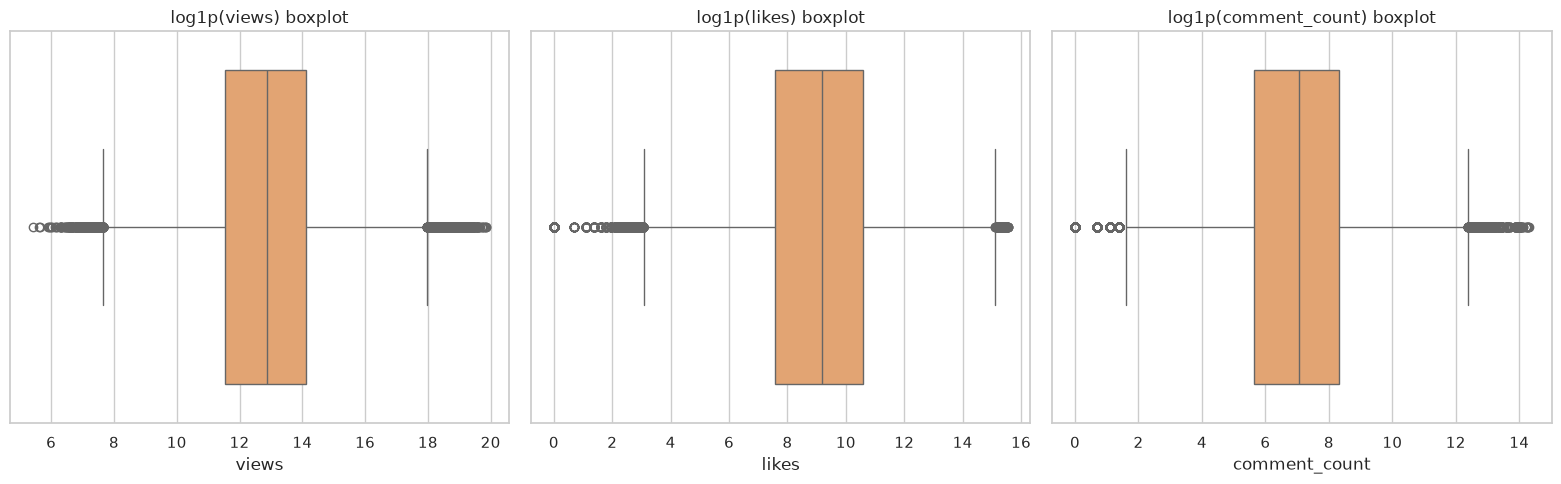

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_columns = ["views", "likes", "comment_count", "engagement_rate", "days_to_trend", "tag_count"]
for ax, column in zip(axes.flat, plot_columns):
    series = df[column].dropna()
    if column in {"views", "likes", "comment_count"}:
        sns.histplot(np.log1p(series), bins=40, ax=ax, color="#2a9d8f")
        ax.set_title(f"log1p({column})")
        ax.set_xlabel(f"log1p({column})")
    else:
        sns.histplot(series, bins=40, ax=ax, color="#2a9d8f")
        ax.set_title(column)
        ax.set_xlabel(column)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, column in zip(axes, ["views", "likes", "comment_count"]):
    sns.boxplot(x=np.log1p(df[column].dropna()), ax=ax, color="#f4a261")
    ax.set_title(f"log1p({column}) boxplot")
plt.tight_layout()
plt.show()

### Time Patterns

These charts summarize how trending activity changes over time and by publishing window.

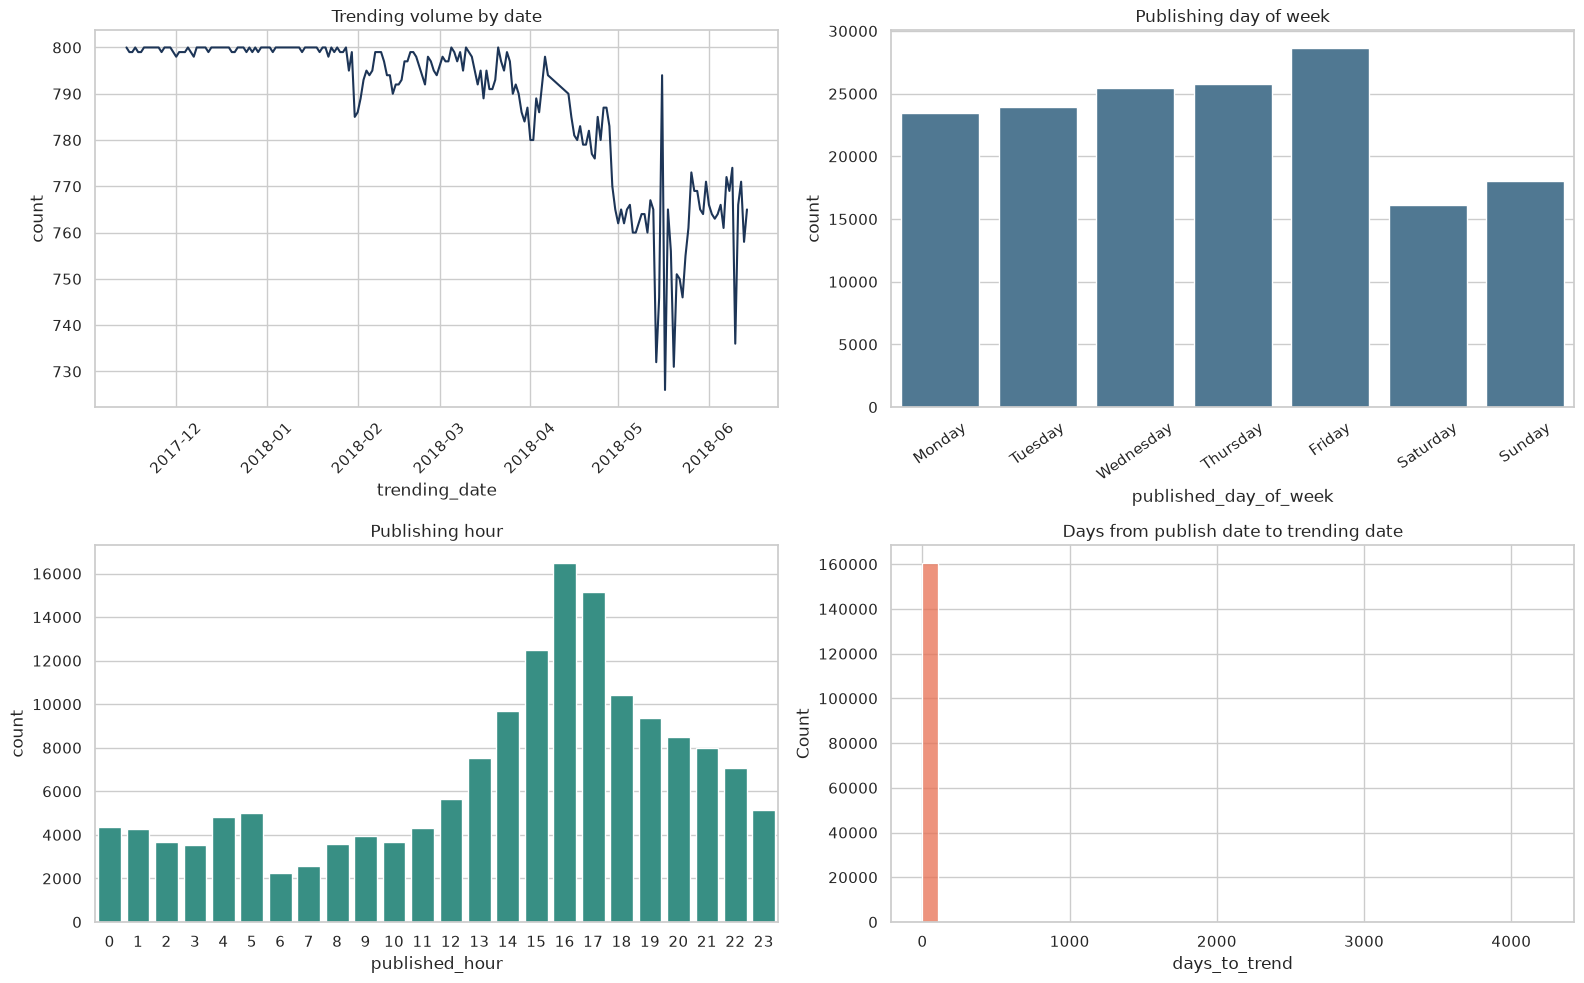

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
daily_trending = df.groupby(df["trending_date"].dt.date).size().reset_index(name="count")
sns.lineplot(data=daily_trending, x="trending_date", y="count", ax=axes[0, 0], color="#1d3557")
axes[0, 0].set_title("Trending volume by date")
axes[0, 0].tick_params(axis="x", rotation=45)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday", "Unknown"]
dow = df["published_day_of_week"].fillna("Unknown").value_counts().reindex(day_order).dropna().reset_index()
dow.columns = ["published_day_of_week", "count"]
sns.barplot(data=dow, x="published_day_of_week", y="count", ax=axes[0, 1], color="#457b9d")
axes[0, 1].set_title("Publishing day of week")
axes[0, 1].tick_params(axis="x", rotation=35)

hour_counts = df["published_hour"].dropna().value_counts().sort_index().reset_index()
hour_counts.columns = ["published_hour", "count"]
sns.barplot(data=hour_counts, x="published_hour", y="count", ax=axes[1, 0], color="#2a9d8f")
axes[1, 0].set_title("Publishing hour")

sns.histplot(df["days_to_trend"].dropna(), bins=40, ax=axes[1, 1], color="#e76f51")
axes[1, 1].set_title("Days from publish date to trending date")
plt.tight_layout()
plt.show()

### Channel-Level Analysis

Channel comparisons focus on channels with enough rows to be meaningful. This reduces noise from channels that appear only once or twice.

,channel_title,trending_frequency,avg_views,median_views,avg_engagement_rate,median_engagement_rate
9545,The Late Show with Stephen Colbert,653,9.798337e+05,819951.0,0.016526,0.014524
5315,Late Night with Seth Meyers,594,1.286973e+06,1364611.0,0.014796,0.013419
9685,TheEllenShow,586,1.607622e+06,1110307.0,0.028044,0.023249
9624,The Tonight Show Starring Jimmy Fallon,569,1.741568e+06,935284.0,0.024828,0.019092
4576,Jimmy Kimmel Live,560,1.709554e+06,1007116.0,0.021350,0.017422
10436,WWE,545,2.458111e+06,1721936.0,0.020562,0.018807
1539,CNN,495,9.935644e+05,389638.0,0.023751,0.021149
9544,The Late Late Show with James Corden,494,2.061846e+06,756147.0,0.030800,0.025453
6931,Netflix,476,1.495447e+06,802483.0,0.024967,0.021140
2751,ESPN,475,4.874291e+05,430708.0,0.013362,0.012332


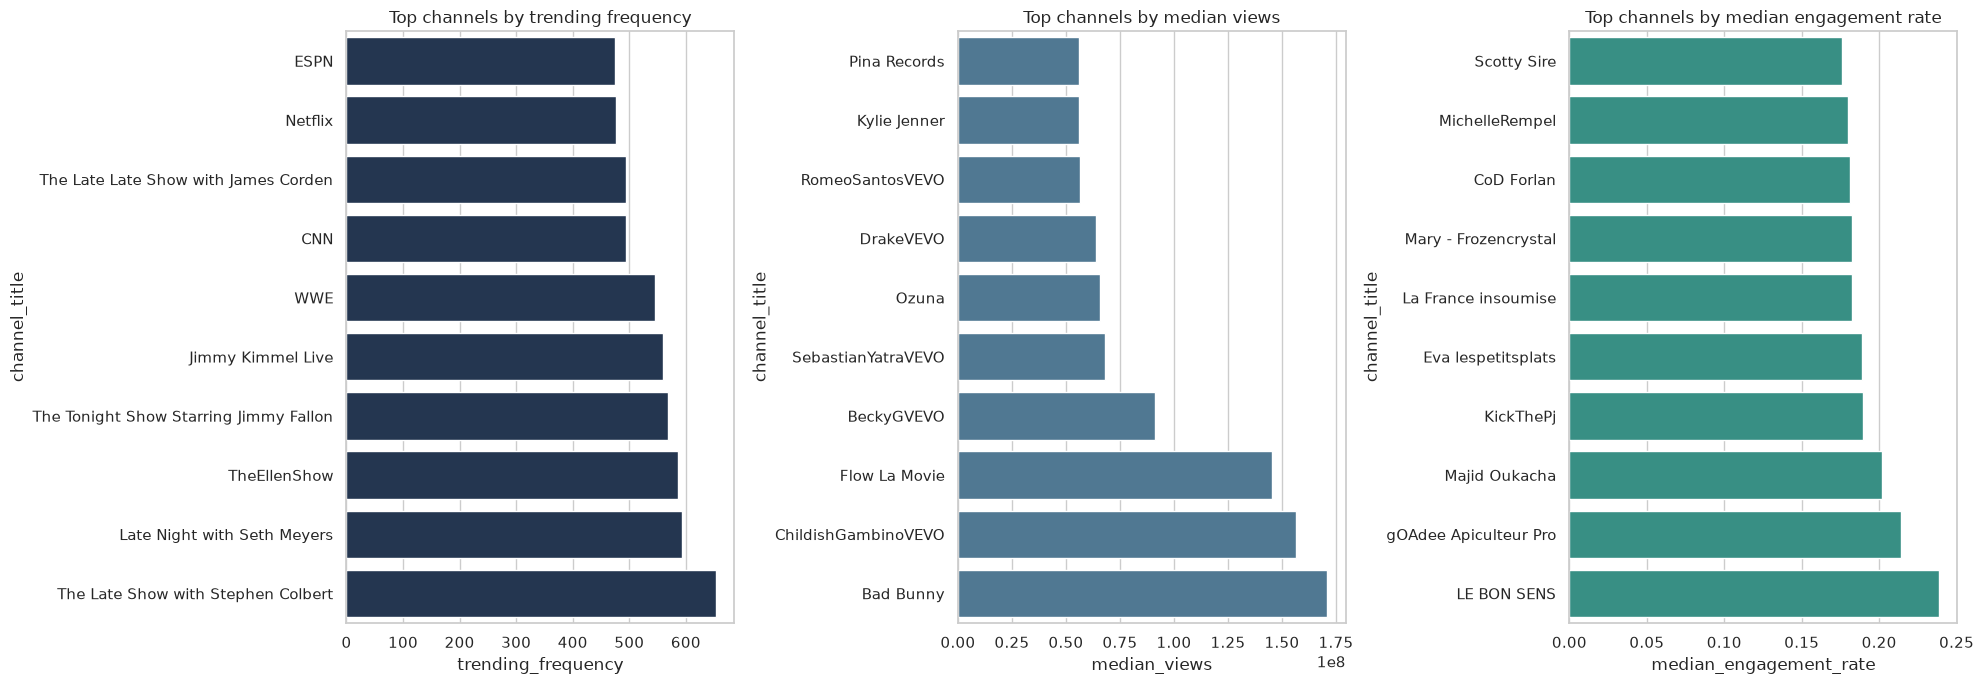

In [6]:
channel_metrics = (
    df.groupby("channel_title")
    .agg(
        trending_frequency=("video_id", "size"),
        avg_views=("views", "mean"),
        median_views=("views", "median"),
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
    )
    .reset_index()
    .sort_values("trending_frequency", ascending=False)
)
channel_metrics = channel_metrics[channel_metrics["trending_frequency"] >= 10]
display(channel_metrics.head(15))

top_channels_freq = channel_metrics.nlargest(10, "trending_frequency").sort_values("trending_frequency")
top_channels_views = channel_metrics.nlargest(10, "median_views").sort_values("median_views")
top_channels_engagement = channel_metrics.nlargest(10, "median_engagement_rate").sort_values("median_engagement_rate")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=top_channels_freq, x="trending_frequency", y="channel_title", ax=axes[0], color="#1d3557")
axes[0].set_title("Top channels by trending frequency")
sns.barplot(data=top_channels_views, x="median_views", y="channel_title", ax=axes[1], color="#457b9d")
axes[1].set_title("Top channels by median views")
sns.barplot(data=top_channels_engagement, x="median_engagement_rate", y="channel_title", ax=axes[2], color="#2a9d8f")
axes[2].set_title("Top channels by median engagement rate")
plt.tight_layout()
plt.show()

### Category-Level Analysis

Category labels are available, so the analysis compares categories by frequency, views, and engagement.

,category_label,trending_frequency,avg_views,median_views,avg_engagement_rate,median_engagement_rate
3,Entertainment,42358,1.601619e+06,378293.5,0.034645,0.024039
8,Music,27903,8.224924e+06,1588813.0,0.048868,0.038449
11,People & Blogs,15960,9.511623e+05,186922.0,0.039907,0.027958
1,Comedy,13401,1.095755e+06,507463.0,0.057733,0.050985
9,News & Politics,11623,4.295408e+05,115852.0,0.028665,0.015844
15,Sports,11210,1.136544e+06,264120.5,0.025798,0.014125
6,Howto & Style,10442,6.998555e+05,269448.0,0.057597,0.050940
4,Film & Animation,9139,2.134199e+06,473236.0,0.034211,0.023570
5,Gaming,5408,1.031163e+06,274947.5,0.055855,0.049148
13,Science & Technology,4876,1.438931e+06,502737.0,0.045420,0.036972


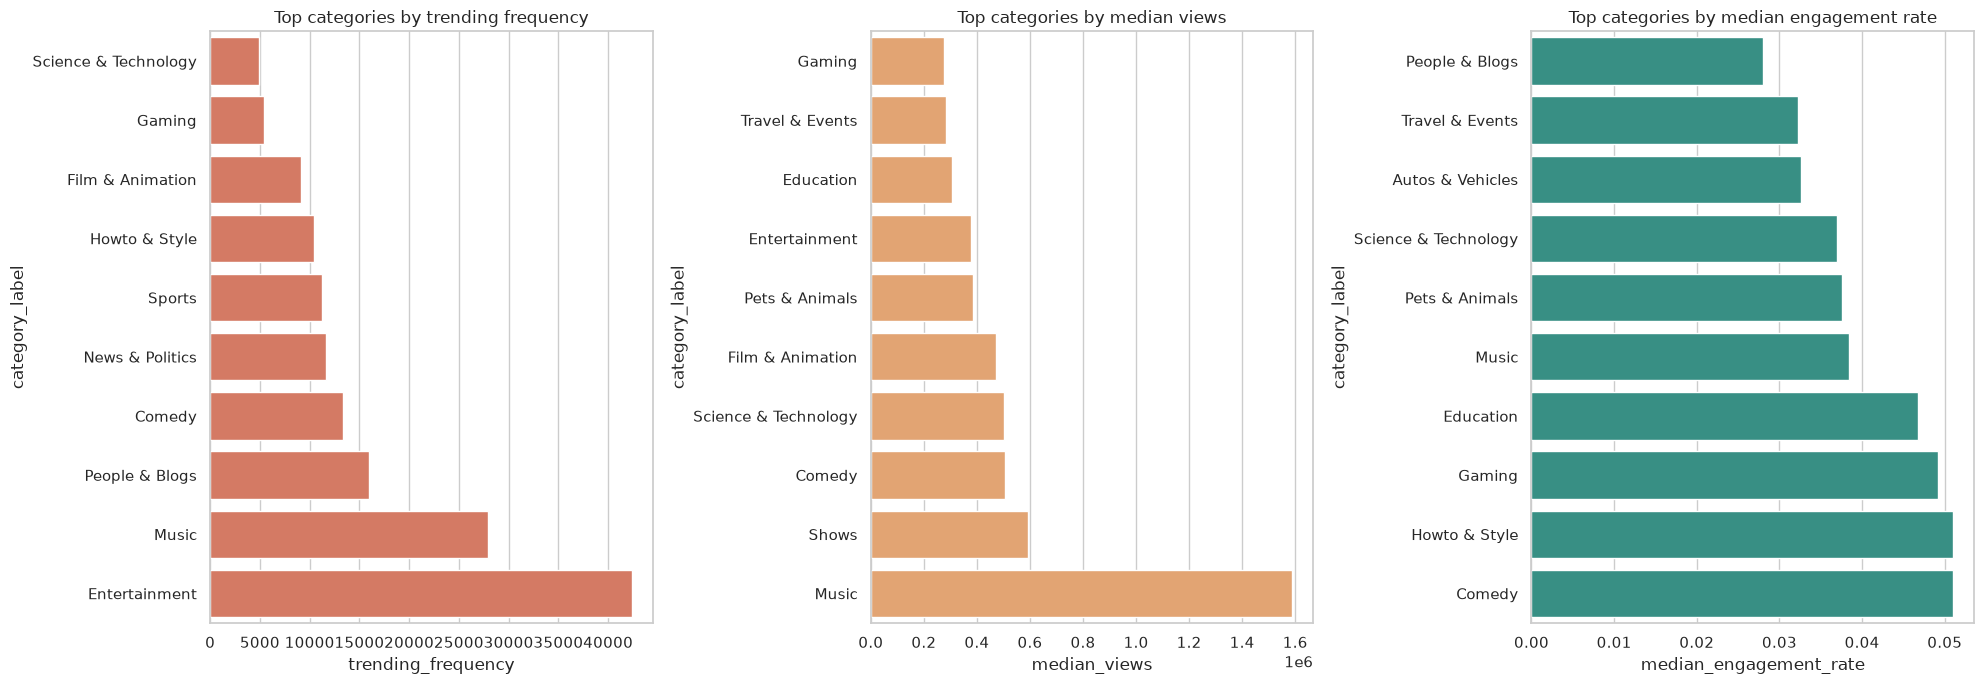

In [7]:
category_metrics = (
    df.groupby("category_label")
    .agg(
        trending_frequency=("video_id", "size"),
        avg_views=("views", "mean"),
        median_views=("views", "median"),
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
    )
    .reset_index()
    .sort_values("trending_frequency", ascending=False)
)
display(category_metrics.head(15))

top_categories_freq = category_metrics.nlargest(10, "trending_frequency").sort_values("trending_frequency")
top_categories_views = category_metrics.nlargest(10, "median_views").sort_values("median_views")
top_categories_engagement = category_metrics.nlargest(10, "median_engagement_rate").sort_values("median_engagement_rate")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.barplot(data=top_categories_freq, x="trending_frequency", y="category_label", ax=axes[0], color="#e76f51")
axes[0].set_title("Top categories by trending frequency")
sns.barplot(data=top_categories_views, x="median_views", y="category_label", ax=axes[1], color="#f4a261")
axes[1].set_title("Top categories by median views")
sns.barplot(data=top_categories_engagement, x="median_engagement_rate", y="category_label", ax=axes[2], color="#2a9d8f")
axes[2].set_title("Top categories by median engagement rate")
plt.tight_layout()
plt.show()

### Correlation Analysis

Views, likes, comments, and engagement are related, but correlations should be interpreted carefully because the variables are highly skewed.

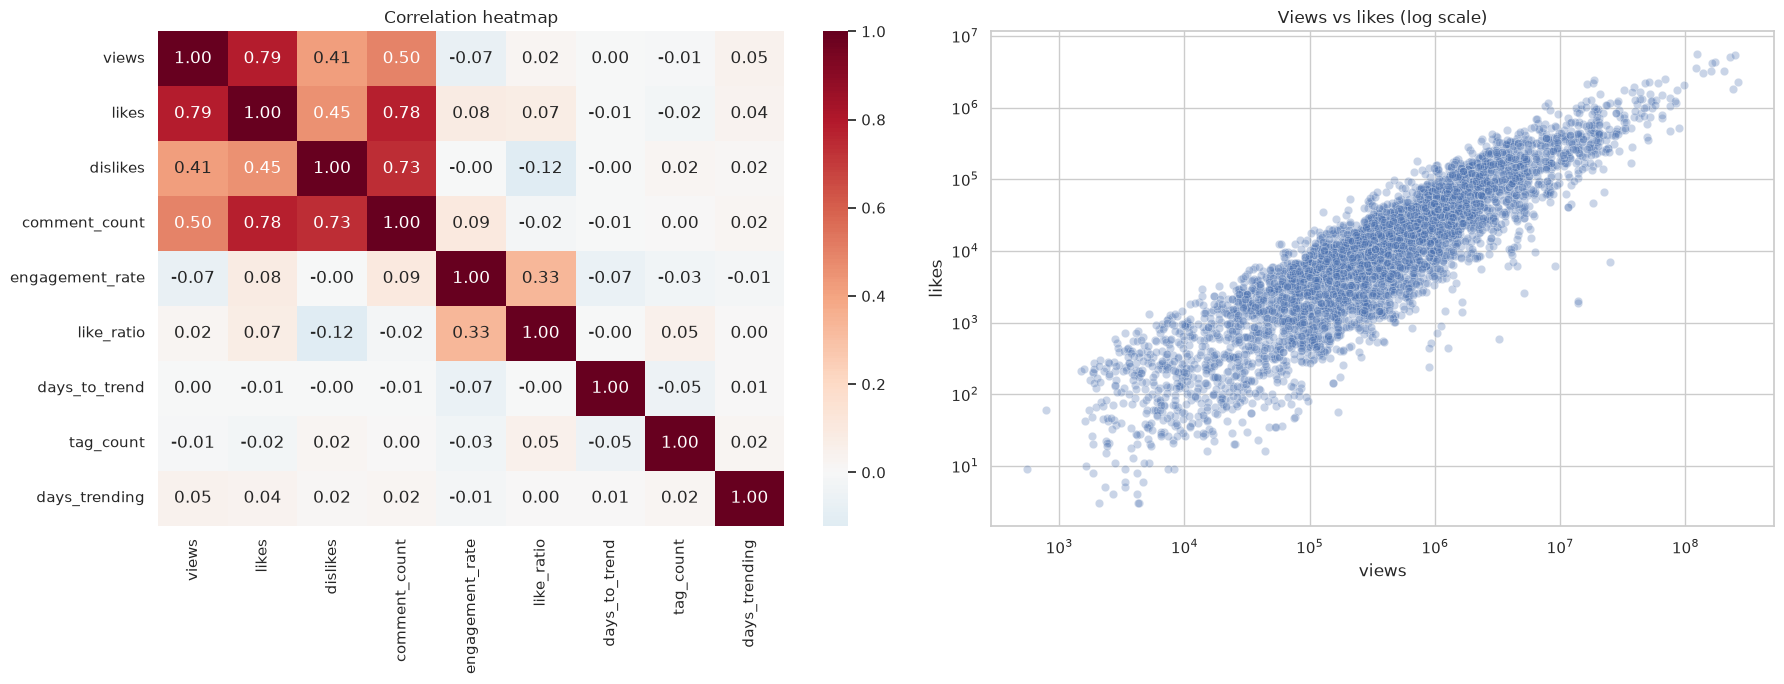

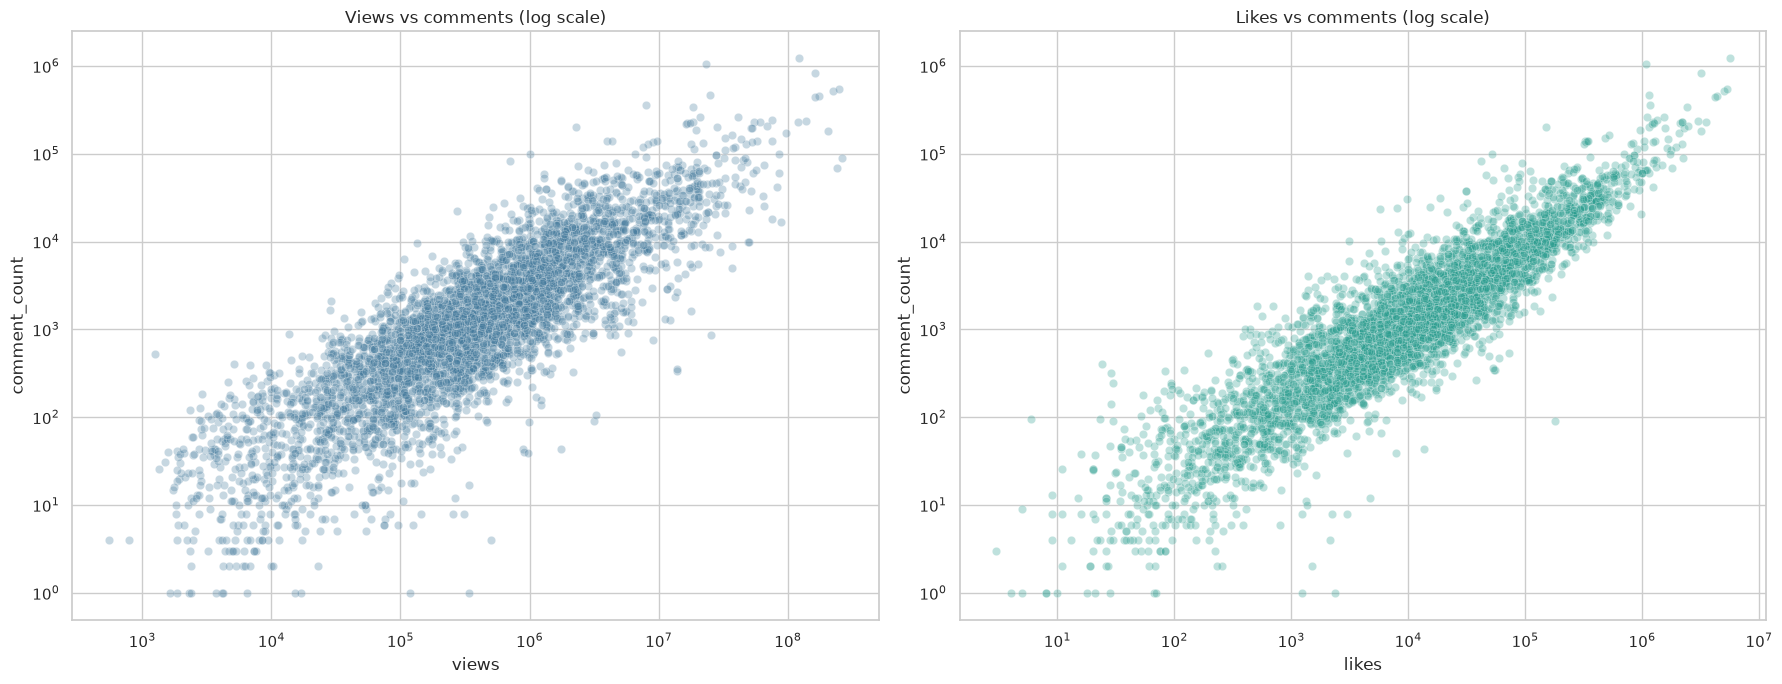

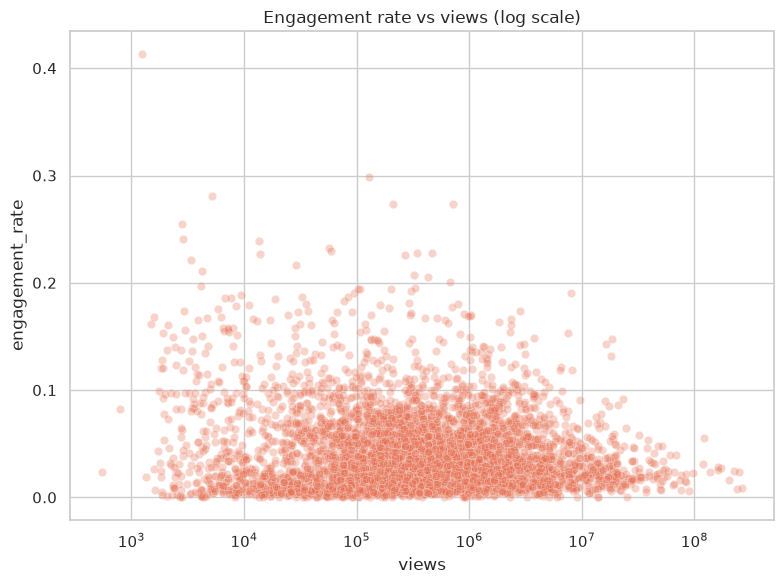

In [8]:
corr_columns = ["views", "likes", "dislikes", "comment_count", "engagement_rate", "like_ratio", "days_to_trend", "tag_count", "days_trending"]
corr = df[corr_columns].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Correlation heatmap")

sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="views", y="likes", alpha=0.3, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Views vs likes (log scale)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="views", y="comment_count", alpha=0.3, ax=axes[0], color="#457b9d")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Views vs comments (log scale)")
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="likes", y="comment_count", alpha=0.3, ax=axes[1], color="#2a9d8f")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Likes vs comments (log scale)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="views", y="engagement_rate", alpha=0.3, ax=ax, color="#e76f51")
ax.set_xscale("log")
ax.set_title("Engagement rate vs views (log scale)")
plt.tight_layout()
plt.show()

### Tag Analysis

Tags are split from the cleaned pipe-delimited field so frequency and performance can be measured at the tag level.

,count
tag,
how to,2979
humour,2984
television,2997
celebrity,3045
vlog,3094
official,3157
review,3167
entertainment,3250
live,3408


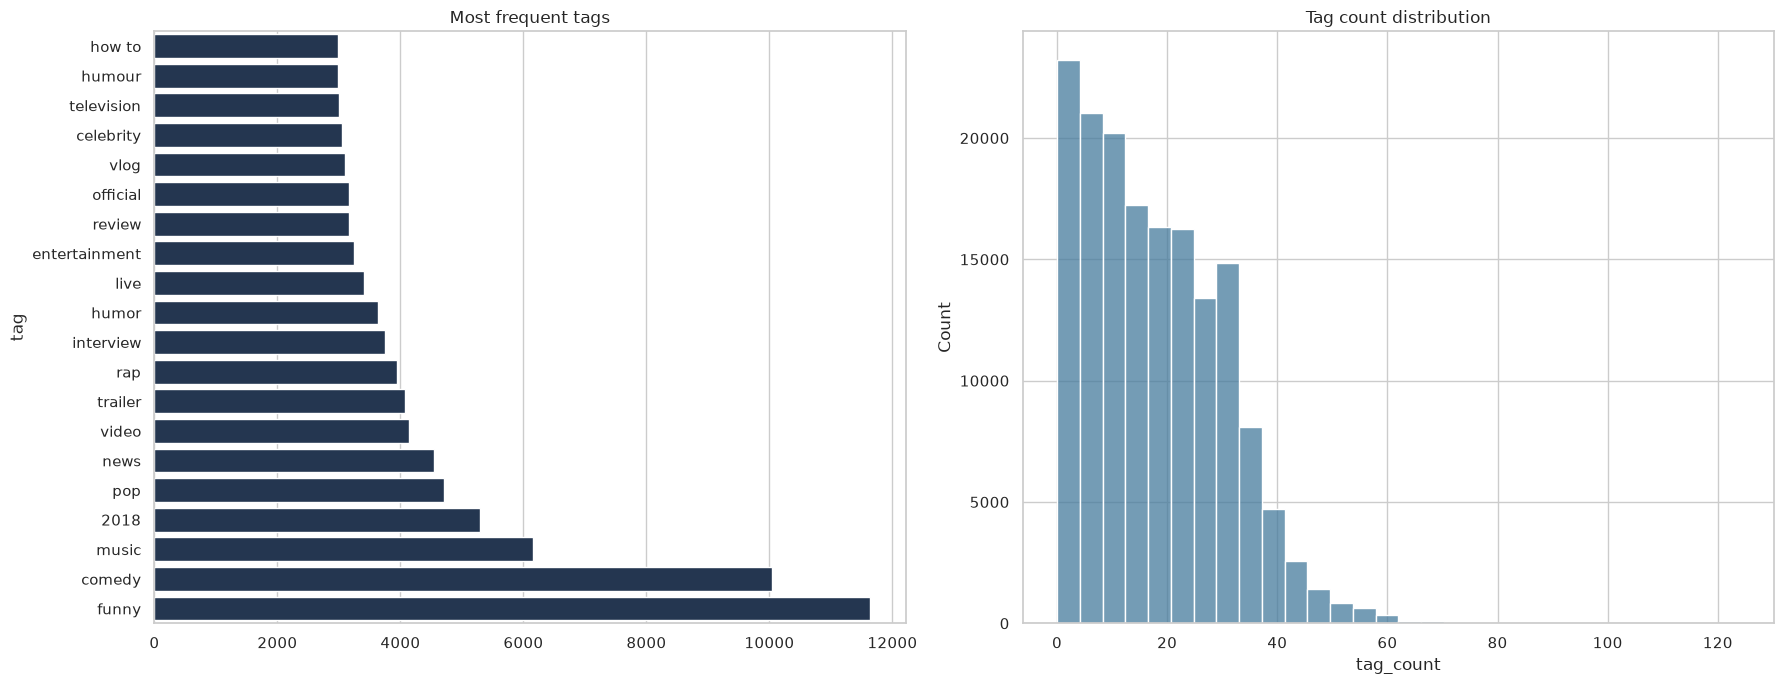

,mentions,avg_views,median_views,avg_engagement_rate,median_engagement_rate
tag,,,,,
apiculture,10,3.484000e+03,3716.0,0.206365,0.211351
hakone,13,9.465846e+04,93718.0,0.190683,0.191511
#vegetarien,11,6.046455e+03,6462.0,0.190394,0.191242
#vegetal,11,5.913364e+03,6141.0,0.192798,0.191242
my parents do my makeup,10,1.598282e+06,1879491.0,0.181051,0.190096
pjthekick,55,8.707949e+04,89046.0,0.197109,0.189832
#vegan,14,5.744000e+03,6139.0,0.188917,0.188928
kickthepj,61,1.446414e+05,91861.0,0.191009,0.187908
#vegetalien,12,6.021250e+03,6299.5,0.187484,0.187392


In [9]:
tag_frame = df.loc[df["tags_clean"].fillna("") != "", ["tags_clean", "views", "engagement_rate", "tag_count"]].copy()
tag_frame["tag"] = tag_frame["tags_clean"].str.split("|")
tag_frame = tag_frame.explode("tag")
tag_frame["tag"] = tag_frame["tag"].astype("string").str.strip()
tag_frame = tag_frame[tag_frame["tag"].notna() & (tag_frame["tag"] != "")]

top_tags = tag_frame["tag"].value_counts().head(20).sort_values()
display(top_tags.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[0], color="#1d3557")
axes[0].set_title("Most frequent tags")

sns.histplot(df["tag_count"].dropna(), bins=30, ax=axes[1], color="#457b9d")
axes[1].set_title("Tag count distribution")
plt.tight_layout()
plt.show()

tag_metrics = (
    tag_frame.groupby("tag")
    .agg(
        mentions=("tag", "size"),
        avg_views=("views", "mean"),
        median_views=("views", "median"),
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
    )
    .query("mentions >= 10")
    .sort_values("median_engagement_rate", ascending=False)
)
display(tag_metrics.head(15))

### Outlier Analysis

Outliers are inspected in terms of views, engagement, and trending duration. The `metric_issue_flag` column helps separate unusual but valid observations from suspicious rows.

In [10]:
display(df.sort_values("views", ascending=False).loc[:, ["video_id", "title", "channel_title", "category_label", "views", "likes", "comment_count", "days_trending", "metric_issue_flag"]].head(10))

display(df.sort_values("engagement_rate", ascending=False).loc[:, ["video_id", "title", "channel_title", "category_label", "engagement_rate", "views", "likes", "comment_count", "days_trending", "metric_issue_flag"]].head(10))

display(df.sort_values("days_trending", ascending=False).loc[:, ["video_id", "title", "channel_title", "category_label", "days_trending", "views", "engagement_rate", "metric_issue_flag"]].head(10))

print("rows flagged for possible metric issues:", int(df["metric_issue_flag"].sum()))

,video_id,title,channel_title,category_label,views,likes,comment_count,days_trending,metric_issue_flag
109937,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,424538912,2818771,99380,36,False
109736,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,413586699,2768654,97218,36,False
109540,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,402650804,2719005,95713,36,False
109348,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,392036878,2670723,93834,36,False
109158,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,382401497,2618320,92387,36,False
108972,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,372399338,2564815,90644,36,False
108788,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,362111555,2506788,89066,36,False
108607,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,349987176,2440754,86952,36,False
108418,_I_D_8Z4sJE,Nicky Jam x J. Balvin - X (EQUIS) | Video Ofic...,NickyJamTV,Music,339629489,2378829,85095,36,False
115929,9jI-z9QN6g8,"Te Bote Remix - Casper, Nio GarcÃ­a, Darell, N...",Flow La Movie,Music,337621571,2581961,113564,33,False


,video_id,title,channel_title,category_label,engagement_rate,views,likes,comment_count,days_trending,metric_issue_flag
62247,Ay7RapOcTow,Nigthcore ( SpÃ©cial 3M ) - Burn,Oka,People & Blogs,0.528285,1096,445,134,1,False
17036,NV-3s2wwC8c,BlocBoy JB & Drake Look Alive Prod By: Tay Kei...,BlocBoy JB,Music,0.506464,38441,17318,2151,7,False
46394,bRnJjFb4D5U,ON VA CASSER LA TIRELIRE POUR LES SDF !,Alex & PJ,Entertainment,0.500512,24433,12090,139,1,False
61237,5KAdKbGt5aA,"NOUVEAUX CONCOURS GAGNE TON KITS SLIMES, SLIME...",Ã‰lodieCrÃ©a,Film & Animation,0.480763,12632,2913,3160,1,False
44611,bxR3G3CS9Io,Ma maman m'a enlevÃ© mon chat...,Forlan TV,People & Blogs,0.478515,11473,2562,2928,1,False
61941,fFVO_FCcnUw,Des Questions ? (pour F.A.Q.),permaculture agroÃ©cologie etc...,Education,0.445312,640,78,207,2,False
10895,a2CUDDhTlyg,GUCCI MADE ME PINK CUSTOM LUGGAGE! + HANDBAG G...,jeffreestar,Howto & Style,0.438307,811601,108516,247214,1,False
6374,unknown,PADMAN Official Trailer | Akshay Kumar | Sonam...,Sony Pictures India,Entertainment,0.434516,178709,71984,5668,525,False
57245,wpysUoQYuGM,NUMBERS - Ã‰pisode 1,Juste Pour Jouer,Entertainment,0.414700,2585,817,255,1,False
61008,woAyL_zyQFo,...â¤,ã€ŒÂ¡ÅžÄ·Ã½Å»Ä™ Art'sâ„¢ã€,Gaming,0.413683,1257,0,520,1,False


,video_id,title,channel_title,category_label,days_trending,views,engagement_rate,metric_issue_flag
56651,unknown,LA LOI OU LE SANG Ep 8 Fin Theatre Congolais A...,topvision1,Film & Animation,530,9652,0.027248,False
52263,unknown,JE MELANGE UN SLIME AVEC DE LA PÃ‚TE INTELLIGE...,Ã‰lodieCrÃ©a,Film & Animation,530,5416,0.093058,False
67745,unknown,L'Heure des Pros (1er dÃ©bat) du 29/03/2018,CNEWS,News & Politics,530,17405,0.013732,False
48059,unknown,IL CORRIGE DES PHOTOS INSATISFAISANTES !,TartinEx,Comedy,530,316609,0.071217,False
48058,unknown,Alerte Rouge : la demande,Lolywood,Comedy,530,1290921,0.069012,False
56047,unknown,Dimanche Tout Est Permis S01 Episode 19 28-01-...,Elhiwar Ettounsi,Entertainment,530,149149,0.005417,False
56046,unknown,"Damso : bilan d'IpsÃ©itÃ©, polÃ©mique hymne de...",Alohanews,Entertainment,530,44292,0.066016,False
56045,unknown,UN ACCIDENT DE DESSIN :'o (Fusion challenge) 2,TutoDraw,Howto & Style,530,278773,0.059443,False
56044,unknown,"IBRA TV, WASS FREESTYLE, JIMMY FAITLCON & DOC ...",FRANCK ROPERS,Sports,530,66444,0.099001,False
56247,unknown,"IBRA TV, WASS FREESTYLE, JIMMY FAITLCON & DOC ...",FRANCK ROPERS,Sports,530,193908,0.067687,False


rows flagged for possible metric issues: 0


## Summary

- Views, likes, and comments are strongly right-skewed, so log-scale views of the distributions are more informative than raw scale.
- Trending volume and publishing patterns can be compared directly by date, weekday, and hour.
- Channels and categories show concentration, with a small number of groups accounting for a large share of trending rows.
- Tag frequency and tag count help identify recurring content themes.
- Outlier review is important because the largest videos can be valid hits or data-quality edge cases.

## Recommendations / Conclusion

- Focus on the channels and categories that repeatedly appear near the top of the trending and median-view tables.
- Use engagement rate alongside views instead of views alone, because the raw view distribution is highly skewed.
- Pay attention to publishing timing: weekday and hour patterns provide a practical scheduling signal.
- Use high-frequency tags as theme indicators, but avoid over-interpreting tags with very few observations.
- Review outliers before turning them into conclusions, especially rows marked by `metric_issue_flag`.